<a href="https://colab.research.google.com/github/melisabozuklu-lang/Numerical-Methods/blob/main/LAB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

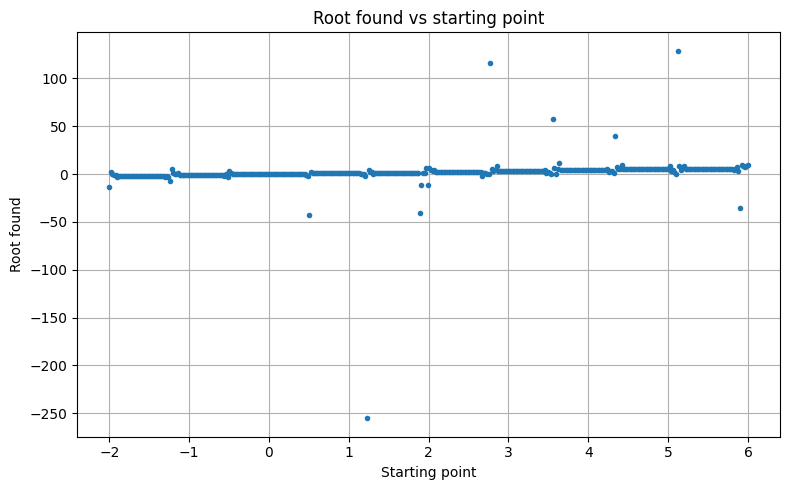

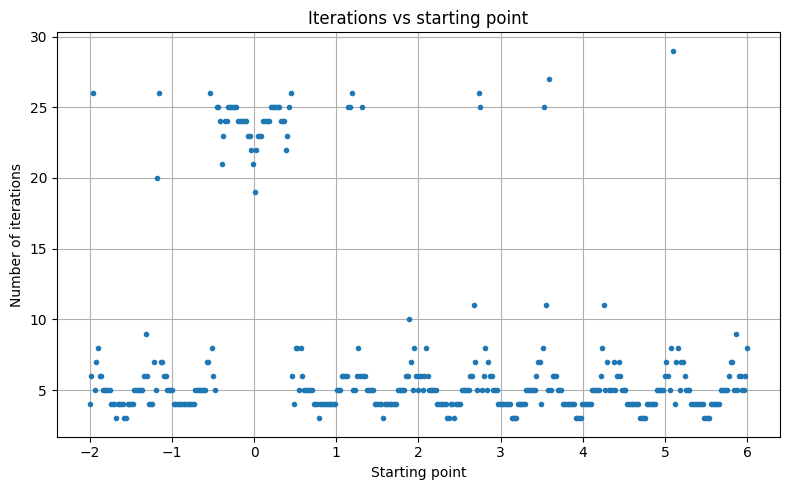

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x * np.sin(4*x)

def df(x):
    return np.sin(4*x) + 4*x*np.cos(4*x)

def newton_1d(x0, tol=1e-8, max_iter=100):
    x = x0

    for i in range(max_iter):

        if abs(df(x)) < 1e-12:
            return np.nan, i

        x_new = x - f(x)/df(x)

        if abs(x_new - x) < tol:
            return x_new, i + 1

        x = x_new

    return x, max_iter

starting_points = np.linspace(-2, 6, 400)

roots = []
iterations = []

for x0 in starting_points:
    root, it = newton_1d(x0)

    roots.append(root)
    iterations.append(it)

roots = np.array(roots)
iterations = np.array(iterations)

plt.figure(figsize=(8,5))
plt.plot(starting_points, roots, '.')
plt.xlabel("Starting point")
plt.ylabel("Root found")
plt.title("Root found vs starting point")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(starting_points, iterations, '.')
plt.xlabel("Starting point")
plt.ylabel("Number of iterations")
plt.title("Iterations vs starting point")
plt.grid(True)
plt.tight_layout()
plt.show()

Conclusion:

Newton's method is sensitive to the starting point.
Different initial guesses converge to different roots.
The number of iterations changes depending on the initial guess.
Some starting points produce unstable behavior and very large root values.

The system is:

x² + y² + z² = 2
x² + y² = 1
x² = y

Function vector:

F1 = x² + y² + z² - 2
F2 = x² + y² - 1
F3 = x² - y

Jacobian matrix:

J = [[2x, 2y, 2z],
     [2x, 2y, 0 ],
     [2x, -1, 0 ]]

In [8]:
def F(v):
    x, y, z = v

    return np.array([
        x**2 + y**2 + z**2 - 2,
        x**2 + y**2 - 1,
        x**2 - y
    ], dtype=float)

def J(v):
    x, y, z = v

    return np.array([
        [2*x, 2*y, 2*z],
        [2*x, 2*y, 0],
        [2*x, -1, 0]
    ], dtype=float)

def newton_system(x0, tol=1e-10, max_iter=50):

    x = np.array(x0, dtype=float)

    for i in range(max_iter):

        delta = np.linalg.solve(J(x), -F(x))

        x = x + delta

        if np.linalg.norm(delta) < tol:
            return x, i + 1

    return x, max_iter

solution, iterations = newton_system([0.8, 0.6, 1.0])

print("Solution:")
print(solution)

print("\nIterations:")
print(iterations)

print("\nCheck:")
print(F(solution))

Solution:
[0.78615138 0.61803399 1.        ]

Iterations:
4

Check:
[ 0.00000000e+00 -1.11022302e-16  0.00000000e+00]


Result:

The Newton method gives the solution:

x = 0.78615138
y = 0.61803399
z = 1.00000000

The method converged in 4 iterations.

The check vector is approximately zero.
Therefore, the solution satisfies the system of equations.

In [9]:
def aitken_acceleration(seq):

    accelerated = []

    for i in range(len(seq)-2):

        x0 = seq[i]
        x1 = seq[i+1]
        x2 = seq[i+2]

        denominator = x2 - 2*x1 + x0

        if abs(denominator) < 1e-12:
            accelerated.append(np.nan)

        else:
            x_acc = x0 - ((x1 - x0)**2) / denominator
            accelerated.append(x_acc)

    return np.array(accelerated)

def newton_sequence(x0, max_iter=10):

    x = x0
    seq = [x]

    for i in range(max_iter):

        x = x - f(x)/df(x)
        seq.append(x)

    return np.array(seq)

seq = newton_sequence(0.5, max_iter=10)

acc_seq = aitken_acceleration(seq)

print("Newton sequence:")
print(seq)

print("\nAitken accelerated sequence:")
print(acc_seq)

Newton sequence:
[ 0.5        -5.40424092 -5.50422863 -5.49779325 -5.49778714 -5.49778714
 -5.49778714 -5.49778714 -5.49778714 -5.49778714 -5.49778714]

Aitken accelerated sequence:
[-5.50595108 -5.4981824  -5.49778714 -5.49778714 -5.49778714         nan
         nan         nan         nan]


Result:

The Newton sequence converges to approximately:

x = -5.49778714

After applying Aitken acceleration, the sequence reaches the same value faster:

x = -5.49778714

The nan values appear because the denominator in Aitken's formula becomes very close to zero after convergence.

Conclusion:

Aitken acceleration can speed up convergence for a one-dimensional sequence.
However, it may become unstable when the denominator is close to zero.

Extra Problem:

Aitken acceleration is originally defined for one-dimensional sequences.
For a multidimensional Newton method, one possible idea is to apply Aitken acceleration separately to each component.

For example, if we have vectors:

X0 = [x0, y0, z0]
X1 = [x1, y1, z1]
X2 = [x2, y2, z2]

then Aitken's formula can be applied component-wise:

X_acc = X0 - (X1 - X0)^2 / (X2 - 2X1 + X0)

This may speed up convergence in some cases.
However, it is not always stable because some components may have denominators close to zero.
Therefore, for multidimensional Newton method, Aitken acceleration can be tried component-wise, but it must be used carefully.

In [10]:
def aitken_vector(X0, X1, X2):
    denominator = X2 - 2*X1 + X0

    result = np.empty_like(X0)

    for i in range(len(X0)):
        if abs(denominator[i]) < 1e-12:
            result[i] = np.nan
        else:
            result[i] = X0[i] - ((X1[i] - X0[i])**2) / denominator[i]

    return result

X0 = np.array([0.8, 0.6, 1.0])
X1 = X0 + np.linalg.solve(J(X0), -F(X0))
X2 = X1 + np.linalg.solve(J(X1), -F(X1))

X_acc = aitken_vector(X0, X1, X2)

print("X0:", X0)
print("X1:", X1)
print("X2:", X2)
print("Aitken accelerated vector:", X_acc)
print("Check F(X_acc):", F(X_acc))

X0: [0.8 0.6 1. ]
X1: [0.78636364 0.61818182 1.        ]
X2: [0.78615141 0.618034   1.        ]
Aitken accelerated vector: [0.78614806 0.61803519        nan]
Check F(X_acc): [            nan -3.73477326e-06 -6.42222865e-06]
